In [2]:
# import relevant libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import os
import string
import pyarrow as pa
import pyarrow.parquet as pq
import fastparquet

In [3]:
# import the cleaned dataset
tracks_df = pd.read_parquet('tracks_df2.parquet', engine='fastparquet')

Linear regression

In [4]:
# import required libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [5]:
# drop irrelevant fields from features list
df_lr = tracks_df.drop(['track_id', 'artists', 'album_name', 'track_name',
                 'artist_alnum', 'album_alnum', 'track_alnum', 'key', 'mode_exp', 'key_exp_all',
                 'time_signature', 'duration_ms', 'duration_min', 'duration_min_rnd0', 'instrumentalness_rnd',
                 'danceability_rnd', 'energy_rnd', 'loudness_rnd', 'speechiness_rnd',
                 'acousticness_rnd', 'liveness_rnd', 'valence_rnd', 'tempo_rnd']
                ,  axis = 1)

In [6]:
# one-hot encode the key_exp variable as it is multilevel
df_lr2 = pd.get_dummies(df_lr, columns = ['key_exp'], drop_first = True)
df_lr2.head()
    

,popularity,explicit,mode,duration_min_rnd,danceability,energy,loudness,speechiness,acousticness,instrumentalness,...,key_exp_B,key_exp_C,key_exp_C♯/D♭,key_exp_D,key_exp_D♯/E♭,key_exp_E,key_exp_F,key_exp_F♯/G♭,key_exp_G,key_exp_G♯/A♭
0,44,True,False,2.7,0.910,0.374,-9.844,0.1990,0.075700,0.00301,...,False,False,False,False,False,False,False,False,False,True
1,47,False,True,5.4,0.269,0.516,-7.361,0.0366,0.406000,0.00000,...,False,True,False,False,False,False,False,False,False,False
2,22,False,False,8.6,0.686,0.560,-13.264,0.0462,0.001140,0.18100,...,False,False,False,False,False,False,True,False,False,False
3,62,False,True,3.2,0.679,0.770,-3.537,0.1900,0.058300,0.00000,...,False,True,False,False,False,False,False,False,False,False
4,19,False,False,5.5,0.519,0.431,-13.606,0.0291,0.000964,0.72000,...,False,False,False,False,False,False,False,True,False,False


In [7]:
# split into features and response, then into training and test
X_lr = df_lr2.drop(columns = 'popularity')
y_lr = df_lr2['popularity']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

In [8]:
# instantiate and fit linear regression  model
model_lr = LinearRegression()
model_lr.fit(X_train_lr, y_train_lr)

# make predictions using the test data
y_pred_lr = model_lr.predict(X_test_lr)

In [9]:
# evaluate the model
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2_lr = r2_score(y_test_lr, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))

In [10]:
print(r2_lr)

0.34737795409055716


In [11]:
print(rmse_lr)

16.645366376565722


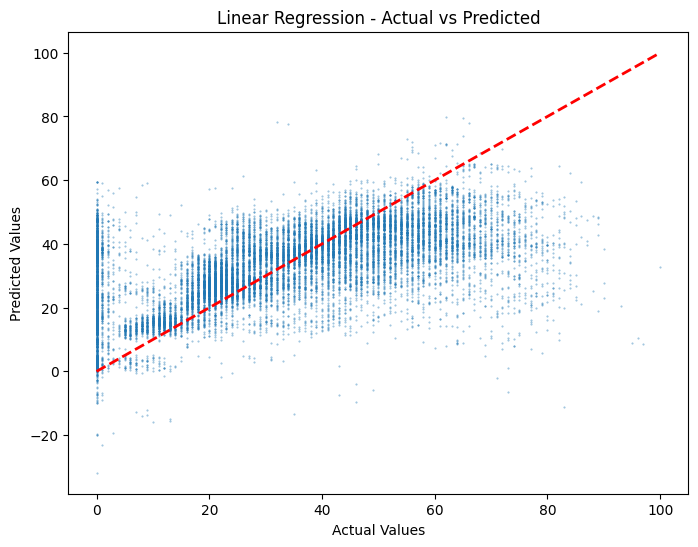

In [15]:
# plot the predicted variables against the actual and plot the residual plot
import matplotlib.pyplot as plt

# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test_lr, y_pred_lr, alpha=0.5, s = 0.2)
plt.plot([y_test_lr.min(), y_test_lr.max()], [y_test_lr.min(), y_test_lr.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression - Actual vs Predicted')
plt.show()

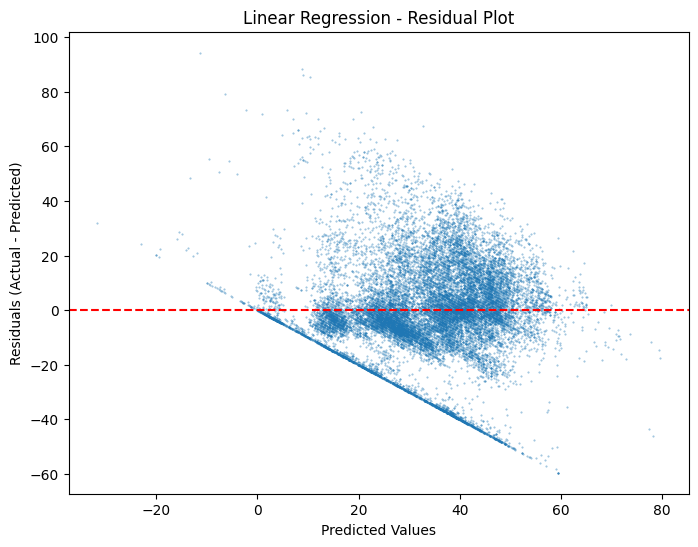

In [14]:
# residual plot
# Residuals = errors
residuals_lr = y_test_lr - y_pred_lr

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_lr, residuals_lr, alpha=0.5, s = 0.2)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Linear Regression - Residual Plot')
plt.show()

Random Forests approach 

In [16]:
# Step 1   drop columns that I'm not going to use in modeling
df_rf = tracks_df.drop(['track_id', 'artists', 'album_name', 'track_name',
                 'artist_alnum', 'album_alnum', 'track_alnum', 'key', 'mode_exp', 'key_exp_all',
                 'time_signature', 'duration_ms', 'duration_min', 'duration_min_rnd0',
                 'danceability_rnd', 'energy_rnd', 'loudness_rnd', 'speechiness_rnd',
                 'acousticness_rnd', 'liveness_rnd', 'valence_rnd', 'tempo_rnd']
                ,  axis = 1)

In [17]:

df_rf.info()
df_rf.sample(n = 10).to_excel('test.xlsx')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89740 entries, 0 to 89739
Columns: 129 entries, popularity to world_music
dtypes: Int64(1), boolean(116), float64(11), object(1)
memory usage: 28.8+ MB


In [18]:
# just need to encode the key exp field
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_rf['key_exp'] = le.fit_transform(df_rf['key_exp'])

In [19]:
# check that it worked
print(df_rf['key_exp'].head())

0    11
1     3
2     8
3     3
4     9
Name: key_exp, dtype: int64


In [11]:
# inspect the encoding
mapping = pd.DataFrame(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

        0   1
0       A   0
1   A♯/B♭   1
2       B   2
3       C   3
4   C♯/D♭   4
5       D   5
6   D♯/E♭   6
7       E   7
8       F   8
9   F♯/G♭   9
10      G  10
11  G♯/A♭  11


In [ ]:
# Step 2 - split into training and test datasets
from sklearn.model_selection import train_test_split

X = df_rf.drop(columns=['popularity'])  # All features
y = df_rf['popularity']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Step 3 - train the random forest
from sklearn.ensemble import RandomForestRegressor

# Create the forest 2
rf_model = RandomForestRegressor(
    n_estimators=100,  # Number of trees in the forest
    random_state=42,   # For reproducible results
    n_jobs=-1          # Use all computer cores
)

# Train it
rf_model.fit(X_train, y_train)  

KeyboardInterrupt: 

In [20]:
# Step 4 make predictions

# Predict on test data
y_pred = rf_model.predict(X_test)


In [21]:
print(y_pred)

[24.31666667 41.05       34.23333333 ... 49.22       44.045
 33.25666026]


In [22]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results.head(20))

       Actual  Predicted
56975      33  24.316667
84350      43  41.050000
18425      20  34.233333
61780      41  41.730000
85825      46  39.540000
46771       0   1.760000
82070      19  36.510000
66350      27  30.100000
71752      20  22.890571
78611      41  49.254000
57984      37  45.060000
72558      67  37.317500
56678      51  45.430000
40803      73  65.053333
33903      68  57.850000
63093      80  35.455000
64580      26  36.360000
53712      32  20.347333
60681      35  38.062000
46155      39  38.691667


Top 10 Most Important Features:
             feature  importance
8       acousticness    0.057125
6           loudness    0.057069
4       danceability    0.054207
12           valence    0.052874
7        speechiness    0.052541
5             energy    0.052017
13             tempo    0.051743
11          liveness    0.047485
3   duration_min_rnd    0.046701
9   instrumentalness    0.034664


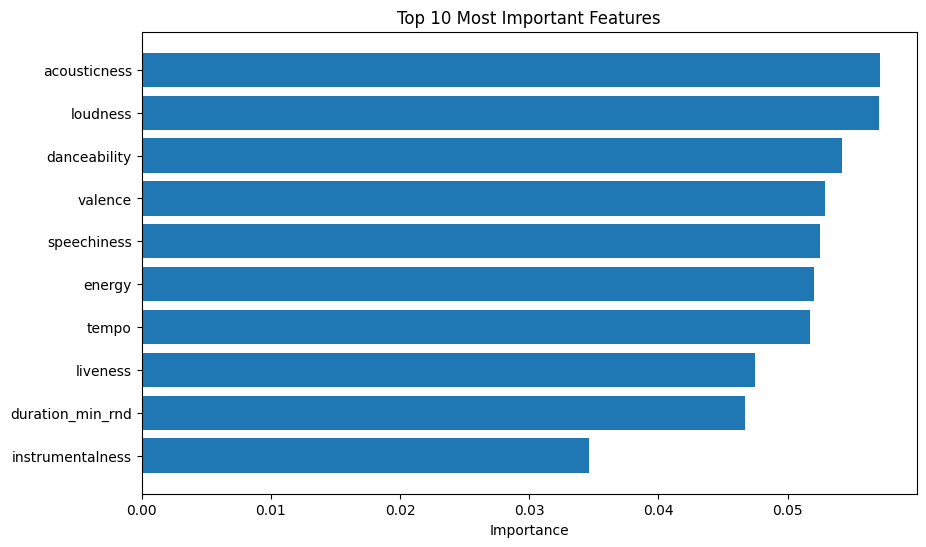

In [ ]:
# see what the most important features are
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(10)['feature'], 
         feature_importance.head(10)['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()  # Most important on top
plt.show()

In [34]:
# Step 5 - evaluate my model
from sklearn.metrics import mean_absolute_error as MAE, mean_squared_error as MSE,r2_score


In [ ]:
# look at the r2 score - 1 is perfect, 0  is no better than just predicting the mean
r2 = r2_score(y_test, y_pred) 
print(r2)

0.5042297326465275


In [ ]:
# Look at the mean absolute Error  - the average difference between the real and actual values in the same units as the target variable
mae = MAE(y_test, y_pred)
print(mae)

9.650376350892175


In [26]:
# root mean squared error - similar to MAE but punishes large errors more heavily
import numpy as np
rmse = np.sqrt(MSE(y_test, y_pred))
print(rmse)

14.507838995965134


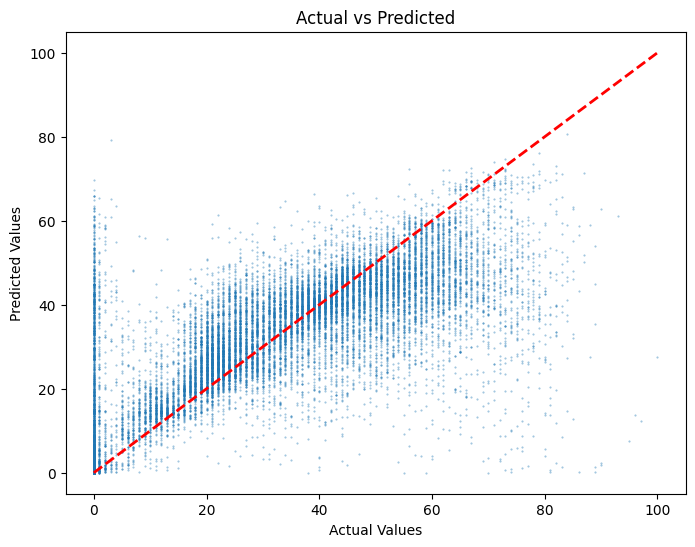

In [ ]:
import matplotlib.pyplot as plt

# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s = 0.2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.show()

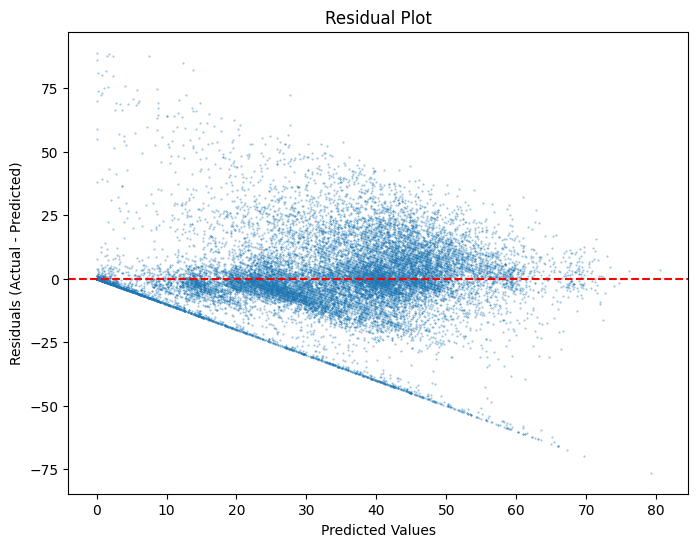

In [31]:
# residual plot
# Residuals = errors
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5, s = 0.2)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

In [32]:
print(f"Model Evaluation:")
print(f"R² Score: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Model Evaluation:
R² Score: 0.504
MAE: 9.65
RMSE: 14.51


In [ ]:
# it seems this model is just ok. I wonder can I improve it by hyper-parameter tuning
# do a grid search
from sklearn.model_selection import GridSearchCV

param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 5],
            }

# define the metrics to use for model evaluation
scoring = {
            'r2': 'r2', 
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error'
}

# define a generic model with the hyperparameters that won't vary
rf = RandomForestRegressor(random_state = 42
                           , n_jobs = -1)

# Define the grid search
gs = GridSearchCV(estimator = rf,
                  param_grid = param_grid, 
                  cv = 5,
                  scoring = scoring,
                  refit = 'r2',
                  return_train_score = True,
                  verbose = 2                           
)

gs.fit(X_train, y_train)

In [41]:
# get the results
results = gs.cv_results_
r2 = results['mean_test_r2']
mae = -results['mean_test_mae']
rmse = -results['mean_test_rmse']

In [42]:
# output the results from best r2 score to worst
rf_results = pd.DataFrame({
    "params": results["params"],
    "r2": r2,
    "mae": mae,
    "rmse": rmse
}).sort_values("r2", ascending=False)

print(rf_results)

                                     params        r2        mae       rmse
2  {'max_depth': None, 'n_estimators': 200}  0.500675   9.716577  14.531914
1  {'max_depth': None, 'n_estimators': 100}  0.498227   9.743513  14.567529
0   {'max_depth': None, 'n_estimators': 50}  0.493023   9.785062  14.642872
4     {'max_depth': 5, 'n_estimators': 100}  0.102238  15.947228  19.485864
3      {'max_depth': 5, 'n_estimators': 50}  0.102100  15.949155  19.487362
5     {'max_depth': 5, 'n_estimators': 200}  0.101983  15.947164  19.488636


In [43]:
print(results)

{'mean_fit_time': array([ 47.79973197,  90.11257854, 175.39836187,   4.60505929,
         8.76041675,  16.87000194]), 'std_fit_time': array([1.00951533, 3.34000704, 4.21172085, 0.21770084, 0.4224322 ,
       0.81636843]), 'mean_score_time': array([0.35940995, 0.46140804, 0.76638522, 0.07320905, 0.09112659,
       0.14157667]), 'std_score_time': array([0.15066276, 0.08917128, 0.11618831, 0.0056914 , 0.00745843,
       0.00902501]), 'param_max_depth': masked_array(data=[None, None, None, 5, 5, 5],
             mask=[False, False, False, False, False, False],
       fill_value=np.str_('?'),
            dtype=object), 'param_n_estimators': masked_array(data=[50, 100, 200, 50, 100, 200],
             mask=[False, False, False, False, False, False],
       fill_value=999999), 'params': [{'max_depth': None, 'n_estimators': 50}, {'max_depth': None, 'n_estimators': 100}, {'max_depth': None, 'n_estimators': 200}, {'max_depth': 5, 'n_estimators': 50}, {'max_depth': 5, 'n_estimators': 100}, {'max_

In [4]:
# this approach didn't help
# what if the group that are not popular are removed?

# make a second version to work with
df_rf2 = df_rf

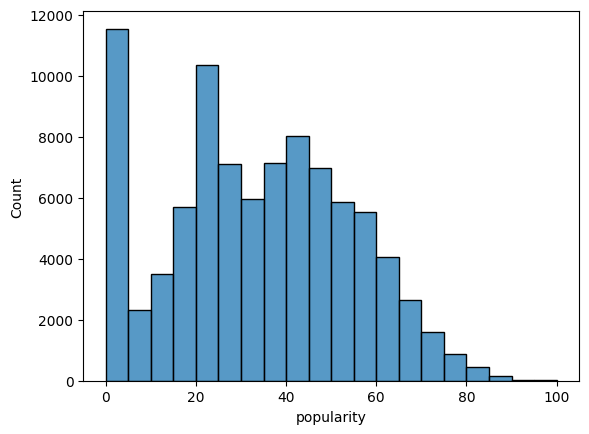

In [15]:
# view a histogram of popularity
sns.histplot(data = df_rf2, x = 'popularity', bins = 20)
plt.show()

In [47]:
# there are a lot where the popularity is less than 5
# investigate this a little
unpop_df = df_rf2[df_rf2['popularity'] <= 5]
print(unpop_df.head())

    popularity  explicit  key_exp  ...  trip_hop  turkish  world_music
6            0     False        4  ...     False    False        False
31           0     False        4  ...     False    False        False
32           0     False        0  ...     False    False        False
39           0     False        9  ...     False    False        False
50           0     False        4  ...     False    False        False

[5 rows x 129 columns]


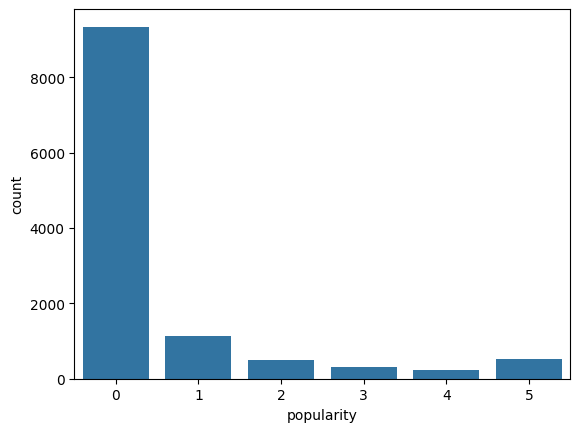

In [48]:
sns.countplot(data = unpop_df, x = 'popularity')
plt.show()

In [5]:
# most are 0, so strip out the zeros as they are likely skewing things a bit
df_rf2 = df_rf2[df_rf2['popularity'] != 0]

In [50]:
df_rf2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80393 entries, 0 to 89739
Columns: 129 entries, popularity to world_music
dtypes: Int64(1), boolean(116), float64(11), int64(1)
memory usage: 26.5 MB


In [ ]:
# run the grid search again to see if this improves the metrics
# first split the new data into training and test

X2 = df_rf2.drop(columns=['popularity'])  # All features
y2 = df_rf2['popularity']  # Your 0-100 target

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)


In [35]:
param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 5]
            }

# define the metrics to use for model evaluation
scoring = {
            'r2': 'r2', 
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error'
}

# define a generic model with the hyperparameters that won't vary
rf = RandomForestRegressor(random_state = 42
                           , n_jobs = -1)

# Define the grid search
gs = GridSearchCV(estimator = rf,
                  param_grid = param_grid, 
                  cv = 5,
                  scoring = scoring,
                  refit = 'r2',
                  return_train_score = True,
                  verbose = 2                           
)

gs.fit(X_train2, y_train2)


NameError: name 'GridSearchCV' is not defined

In [66]:
# get the results
results = gs.cv_results_
r2 = results['mean_test_r2']
mae = -results['mean_test_mae']
rmse = -results['mean_test_rmse']

In [67]:
# output the results from best r2 score to worst
rf_results = pd.DataFrame({
    "params": results["params"],
    "r2": r2,
    "mae": mae,
    "rmse": rmse
}).sort_values("r2", ascending=False)

print(rf_results)

                                     params        r2        mae       rmse
2  {'max_depth': None, 'n_estimators': 200}  0.511356   8.844028  12.700461
1  {'max_depth': None, 'n_estimators': 100}  0.509228   8.864599  12.728115
0   {'max_depth': None, 'n_estimators': 50}  0.503917   8.906948  12.796823
4     {'max_depth': 5, 'n_estimators': 100}  0.155382  13.585629  16.697861
5     {'max_depth': 5, 'n_estimators': 200}  0.154969  13.589118  16.701937
3      {'max_depth': 5, 'n_estimators': 50}  0.154770  13.588961  16.703906


In [ ]:
# minimal improvement


In [6]:
# trying lightgbm
import lightgbm as lgb

In [7]:
# take the df_rf data and split it into training, test and validation
df_rf2['key_exp'] = df_rf2['key_exp'].astype('category')

C:\Users\Anne\AppData\Local\Temp\ipykernel_20564\199292349.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rf2['key_exp'] = df_rf2['key_exp'].astype('category')


In [ ]:
# define which fields are categorical
cat_cols = df_rf2.select_dtypes(include=['category']).columns.tolist()
print(cat_cols)

['key_exp']


In [9]:
# create training, validation and test datasets
# Use the scikit-learn workflow to split into training, validation and test
# LightGBM does not handle training test split by design
from sklearn.model_selection import train_test_split

# setting a 3 as a suffix to all as this is the third time splitting the data into sets
X3 = df_rf2.drop(columns=['popularity'])  # i.e. everything except the response variable
y3 = df_rf2['popularity']  # response variable

# for datasets < 100k records, a 70-15-15 split (training-validation-test) is a reasonable start
# > 100k records, increase training size e.g. 80 to 90, then 5-10, 5-10
# example approach for 70-15-15

# Step 1: Hold out the test set (15%)
X_temp3, X_test3, y_temp3, y_test3 = train_test_split(
    X3, y3, test_size=0.15, random_state=42, shuffle=True
)

# Step 2: Split remaining 85% into training (70%) and validation (15%)
X_train3, X_val3, y_train3, y_val3 = train_test_split(
    X_temp3, y_temp3, test_size=0.1765, random_state=42, shuffle=True
)
# 0.1765 ≈ 12.75% / 85% to make final val set 15% of total

In [ ]:
# Convert to lgb.Dataset objects
# Training dataset
train_set = lgb.Dataset(
    X_train3,
    label=y_train3,
    categorical_feature=cat_cols,  # optional, but recommended
)

# Validation dataset
valid_set = lgb.Dataset(
    X_val3,
    label=y_val3,
    categorical_feature=cat_cols,
    reference=train_set  # links to training data for efficiency
)

# Test dataset (optional for evaluation)
test_set = lgb.Dataset(
    X_test3,
    label=y_test3,
    categorical_feature=cat_cols,
    reference=train_set
)

In [12]:
# define reasonable baseline parameters to fit an initial model
lgb_params = {
    # Objective and evaluation 
    "objective": "regression",
    "metric": ["rmse","mae"], # note r2_score is not natively in lgb, but these two will do for the training metric
    # Boosting control metrics
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    # Tree complexity
    "num_leaves": 31, # 31-63 is a good common starting point 
    "max_depth": -1, # -1 is default (no limit)
    # Regularization
    "min_data_in_leaf": 100, # Default is 20. Small datasets 30-100, large datasets 20-50
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    # Training control
    "seed" : 42,
}

In [13]:
# train the model
model = lgb.train(
    params=lgb_params,
    train_set=train_set,
    valid_sets=[train_set, valid_set],
    valid_names=["train", "valid"],
    num_boost_round=5000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=200),
        lgb.log_evaluation(period=200),
    ],
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019023 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2803
[LightGBM] [Info] Number of data points in the train set: 56273, number of used features: 128
[LightGBM] [Info] Start training from score 37.062126
Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 12.7542	train's l1: 9.2182	valid's rmse: 12.9965	valid's l1: 9.33702
[400]	train's rmse: 12.2218	train's l1: 8.76584	valid's rmse: 12.8551	valid's l1: 9.13228
[600]	train's rmse: 11.8252	train's l1: 8.47057	valid's rmse: 12.8116	valid's l1: 9.06396
[800]	train's rmse: 11.4893	train's l1: 8.22788	valid's rmse: 12.7876	valid's l1: 9.03353
[1000]	train's rmse: 11.1909	train's l1: 8.01609	valid's rmse: 12.7932	valid's l1: 9.02264
Early stopping, best iteration is:
[822]	train's rmse: 11.4543	train's l1: 8.202

In [15]:
# evaluate on test set
from sklearn.metrics import r2_score
y_test_pred3 = model.predict(X_test3, num_iteration=model.best_iteration)

test_r2 = r2_score(y_test3, y_test_pred3)
print(f"Test R2: {test_r2:.4f}")

Test R2: 0.5282


In [23]:
# a marginal improvement. Try randomized search to find better parameters
# define base parameters that won't change in rs
base_params = {
    "objective": "regression",
    "metric": "rmse",
    "verbosity": -1,
    "seed": 42,
    #"feature_pre_filter": False, # allows tuning of min_data_in_leaf
}


In [25]:
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(42)

best_rmse = float("inf")
best_params = None
best_iter = None

n_trials = 30  # keep it small/fast

for i in range(n_trials):
    # 1) sample hyperparameters
    trial_params = {
        "num_leaves": int(rng.integers(16, 128)),
        "feature_fraction": float(rng.uniform(0.7, 1.0)),
        "bagging_fraction": float(rng.uniform(0.7, 1.0)),
        "bagging_freq": 1,  # bagging_fraction only works if freq > 0
    }

    params = {**base_params, **trial_params}

    # 2) train with early stopping
    model = lgb.train(
        params,
        train_set,
        num_boost_round=3000,
        valid_sets=[valid_set],
        valid_names=["valid"],
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(0),
        ],
    )

    # 3) score on validation (RMSE)
    y_pred3 = model.predict(X_val3, num_iteration=model.best_iteration)
    rmse = np.sqrt(mean_squared_error(y_val3, y_pred3))  # version-safe RMSE

    # 4) print progress + keep best
    print(f"Trial {i+1}/{n_trials} | rmse={rmse:.4f} | best_iter={model.best_iteration}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_params = trial_params
        best_iter = model.best_iteration

print("\nBest validation RMSE:", best_rmse)
print("Best params:", best_params)
print("Best iteration:", best_iter)


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[569]	valid's rmse: 12.6349
Trial 1/30 | rmse=12.6349 | best_iter=569
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[98]	valid's rmse: 12.6764
Trial 2/30 | rmse=12.6764 | best_iter=98
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[173]	valid's rmse: 12.6355
Trial 3/30 | rmse=12.6355 | best_iter=173
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[87]	valid's rmse: 12.6379
Trial 4/30 | rmse=12.6379 | best_iter=87
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[175]	valid's rmse: 12.6381
Trial 5/30 | rmse=12.6381 | best_iter=175
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[162]	valid's rmse: 12.7219
Trial 6/30 | rmse=12.7219 | best_iter=162
Tr

In [26]:
# check the r2 score of the best iteration
from sklearn.metrics import r2_score

y_pred4 = model.predict(X_val3, num_iteration=model.best_iteration)
r2 = r2_score(y_val3, y_pred4)

print("Validation R² at best iteration:", r2)


Validation R² at best iteration: 0.5052147582167531


In [29]:
# no improvement
residuals3 = y_test3 - y_pred4
print("Residual mean:", residuals.mean())
print("Residual std:", residuals.std())

ValueError: operands could not be broadcast together with shapes (12059,) (12061,) 